# 01 — Data Exploration (Project K)
**Goal:** Understand the dataset before training any model.

Questions to answer (from the project specification):
1. What classes are in the dataset?
2. What is the distribution of images?  Are there imbalances?
3. What properties of the images could affect model training and performance?

> **Prerequisite:** Run `python scripts/prepare_dataset_oiv7.py --out data --max-samples 3000 --seed 42`
> so that `data/train/` and `data/test/` are populated.

In [1]:
import os
import glob
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter

# Reproducibility
random.seed(42)
np.random.seed(42)

# Plot style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

In [2]:
# ── Paths (relative to repository root) ──────────────────────
TRAIN_DIR = os.path.join("..", "data", "train")
TEST_DIR = os.path.join("..", "data", "test")
CLASSES = ["Apple", "Banana", "Lemon"]

# Verify that the dataset exists
for split_name, split_dir in [("train", TRAIN_DIR), ("test", TEST_DIR)]:
	if not os.path.isdir(split_dir):
		raise FileNotFoundError(
			f"{split_name} directory not found at '{split_dir}'. "
			f"Run the dataset preparation script first."
		)
	for cls in CLASSES:
		cls_dir = os.path.join(split_dir, cls)
		if not os.path.isdir(cls_dir):
			raise FileNotFoundError(
				f"Class directory not found: '{cls_dir}'. "
				f"Check that the dataset was downloaded correctly."
			)

print("Dataset directories verified OK.")

Dataset directories verified OK.


In [3]:
# ── Load metadata saved by the preparation script ────────────
info_path = os.path.join("..", "data", "dataset_info.json")

if os.path.isfile(info_path):
	with open(info_path, "r") as f:
		dataset_info = json.load(f)
	print("Dataset metadata")
	print(f"  Source       : {dataset_info.get('source', 'N/A')}")
	print(f"  Created at   : {dataset_info.get('created_at', 'N/A')}")
	print(f"  Seed         : {dataset_info.get('seed', 'N/A')}")
	print(f"  Test fraction: {dataset_info.get('test_frac', 'N/A')}")
	print(f"  Total patches: {dataset_info.get('num_patches_total', 'N/A')}")
else:
	print("dataset_info.json not found — skipping metadata display.")

Dataset metadata
  Source       : open-images-v7 (detections → patches)
  Created at   : 2026-02-27T23:33:35
  Seed         : 42
  Test fraction: 0.25
  Total patches: 12819


## 1. Class distribution

In [4]:
def count_images(base_dir, classes):
	"""Count image files per class in a directory tree."""
	ext = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp")
	counts = {}
	for cls in classes:
		cls_dir = os.path.join(base_dir, cls)
		files = []
		for pattern in ext:
			files.extend(glob.glob(os.path.join(cls_dir, pattern)))
			files.extend(glob.glob(os.path.join(cls_dir, pattern.upper())))
		counts[cls] = len(files)
	return counts


train_counts = count_images(TRAIN_DIR, CLASSES)
test_counts = count_images(TEST_DIR, CLASSES)

# Build a summary dataframe
df_counts = pd.DataFrame({
	"Class": CLASSES,
	"Train": [train_counts[c] for c in CLASSES],
	"Test": [test_counts[c] for c in CLASSES],
})
df_counts["Total"] = df_counts["Train"] + df_counts["Test"]
df_counts["Train %"] = (df_counts["Train"] / df_counts["Train"].sum() * 100).round(1)
df_counts["Test %"] = (df_counts["Test"] / df_counts["Test"].sum() * 100).round(1)

print("Image counts per class")
print("=" * 55)
print(df_counts.to_string(index=False))
print()
print(f"Total train : {df_counts['Train'].sum()}")
print(f"Total test  : {df_counts['Test'].sum()}")
print(f"Total images: {df_counts['Total'].sum()}")
print(f"Actual split: {df_counts['Train'].sum() / df_counts['Total'].sum():.1%} / "
	  f"{df_counts['Test'].sum() / df_counts['Total'].sum():.1%}")

Image counts per class
 Class  Train  Test  Total  Train %  Test %
 Apple   2913   974   3887     53.2    54.2
Banana   1209   409   1618     22.1    22.8
 Lemon   1352   413   1765     24.7    23.0

Total train : 5474
Total test  : 1796
Total images: 7270
Actual split: 75.3% / 24.7%


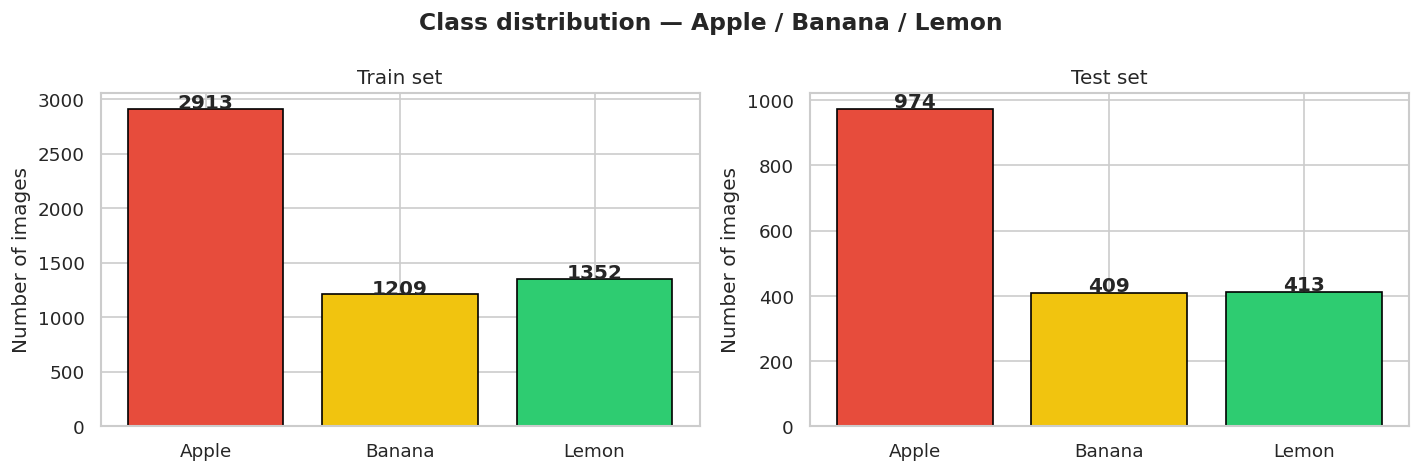

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colours = {"Apple": "#e74c3c", "Banana": "#f1c40f", "Lemon": "#2ecc71"}
bar_colours = [colours[c] for c in CLASSES]

# Train split
axes[0].bar(CLASSES, [train_counts[c] for c in CLASSES], color=bar_colours, edgecolor="black")
axes[0].set_title("Train set")
axes[0].set_ylabel("Number of images")
for i, c in enumerate(CLASSES):
	axes[0].text(i, train_counts[c] + 5, str(train_counts[c]), ha="center", fontweight="bold")

# Test split
axes[1].bar(CLASSES, [test_counts[c] for c in CLASSES], color=bar_colours, edgecolor="black")
axes[1].set_title("Test set")
axes[1].set_ylabel("Number of images")
for i, c in enumerate(CLASSES):
	axes[1].text(i, test_counts[c] + 5, str(test_counts[c]), ha="center", fontweight="bold")

fig.suptitle("Class distribution — Apple / Banana / Lemon", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join("..", "reports", "class_distribution.png"), bbox_inches="tight")
plt.show()

## 2. Imbalance analysis

In [6]:
train_vals = list(train_counts.values())
imbalance_ratio = max(train_vals) / max(min(train_vals), 1)

print(f"Largest class  : {max(train_counts, key=train_counts.get)} ({max(train_vals)} images)")
print(f"Smallest class : {min(train_counts, key=train_counts.get)} ({min(train_vals)} images)")
print(f"Imbalance ratio: {imbalance_ratio:.2f}x")
print()

if imbalance_ratio < 1.5:
	print("The dataset is reasonably balanced (ratio < 1.5).")
	print("No special class-weighting or oversampling is required.")
elif imbalance_ratio < 3.0:
	print("Moderate imbalance detected (ratio 1.5 – 3.0).")
	print("Consider using class weights during training or oversampling the minority class.")
else:
	print("Significant imbalance detected (ratio > 3.0).")
	print("Class weights, oversampling, or under-sampling should be applied.")

Largest class  : Apple (2913 images)
Smallest class : Banana (1209 images)
Imbalance ratio: 2.41x

Moderate imbalance detected (ratio 1.5 – 3.0).
Consider using class weights during training or oversampling the minority class.


## 3. Sample images

A visual inspection of representative images from each class.

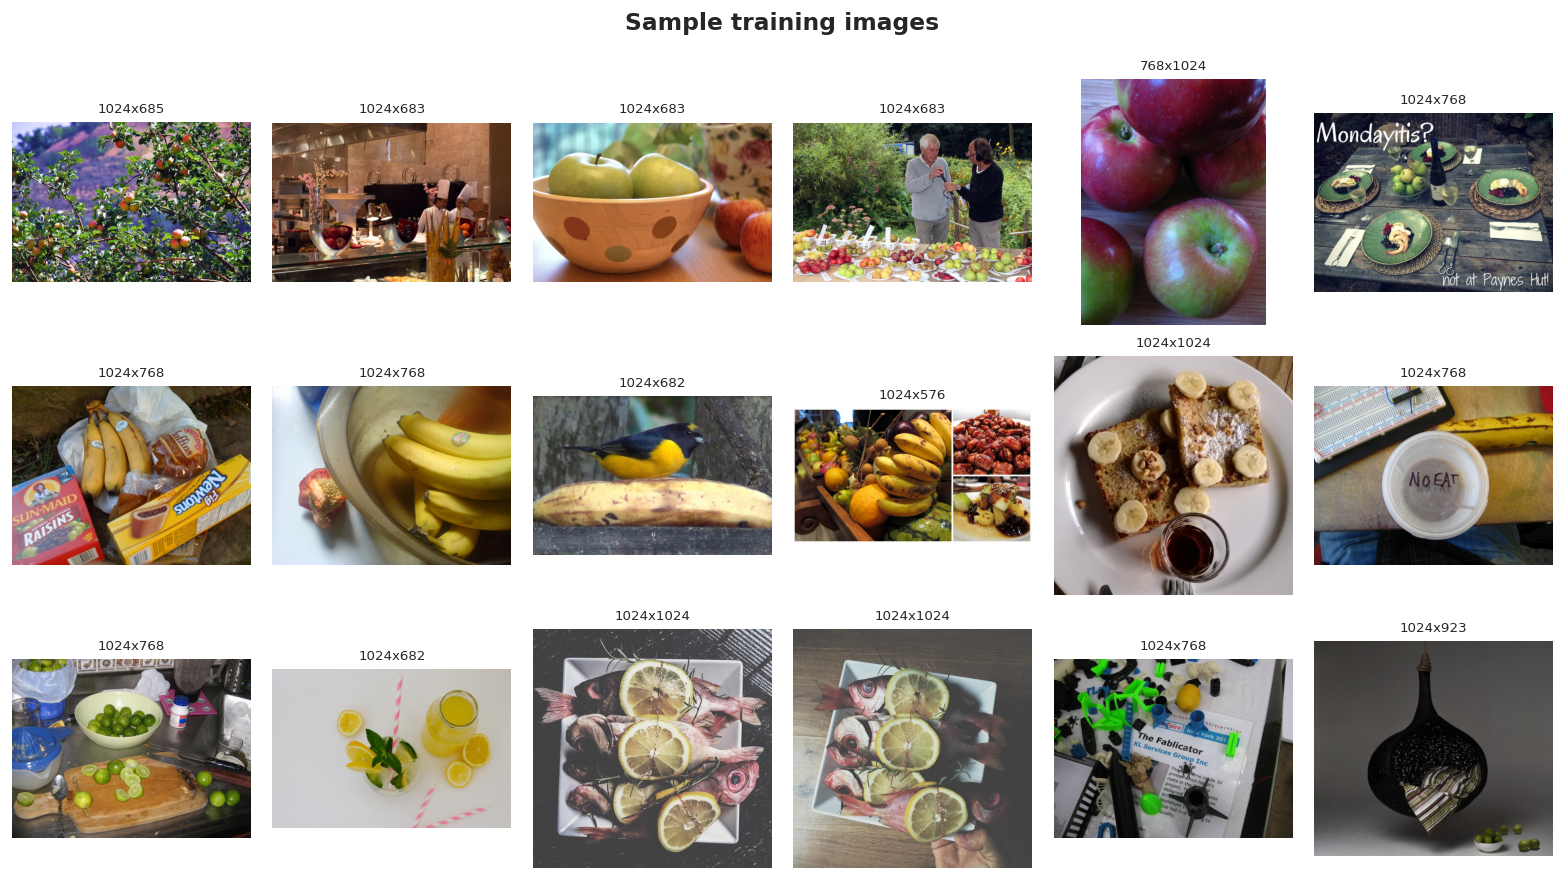

In [7]:
def get_image_paths(base_dir, cls, n=6):
	"""Return up to *n* random image paths from a class directory."""
	ext = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp")
	paths = []
	cls_dir = os.path.join(base_dir, cls)
	for pattern in ext:
		paths.extend(glob.glob(os.path.join(cls_dir, pattern)))
		paths.extend(glob.glob(os.path.join(cls_dir, pattern.upper())))
	random.shuffle(paths)
	return paths[:n]


n_samples = 6  # images per class
fig, axes = plt.subplots(len(CLASSES), n_samples, figsize=(n_samples * 2.2, len(CLASSES) * 2.5))

for row, cls in enumerate(CLASSES):
	paths = get_image_paths(TRAIN_DIR, cls, n=n_samples)
	for col in range(n_samples):
		ax = axes[row][col]
		if col < len(paths):
			img = Image.open(paths[col]).convert("RGB")
			ax.imshow(img)
			if col == 0:
				ax.set_ylabel(cls, fontsize=12, fontweight="bold", rotation=0, labelpad=50)
			w, h = img.size
			ax.set_title(f"{w}x{h}", fontsize=8)
		ax.axis("off")

fig.suptitle("Sample training images", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join("..", "reports", "sample_images.png"), bbox_inches="tight")
plt.show()

## 4. Image dimensions analysis

Since the dataset is built from **object-detection crops** (bounding-box patches),
image sizes will vary significantly. Understanding this is important because
VGG-16 expects a fixed input of **224 × 224 × 3**.

In [8]:
def collect_image_sizes(base_dir, classes):
	"""Read width/height of every image, return a DataFrame."""
	ext = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp")
	rows = []
	for cls in classes:
		cls_dir = os.path.join(base_dir, cls)
		paths = []
		for pattern in ext:
			paths.extend(glob.glob(os.path.join(cls_dir, pattern)))
			paths.extend(glob.glob(os.path.join(cls_dir, pattern.upper())))
		for p in paths:
			try:
				with Image.open(p) as im:
					w, h = im.size
				rows.append({"class": cls, "width": w, "height": h, "aspect": w / h})
			except Exception:
				continue  # skip corrupt files
	return pd.DataFrame(rows)


print("Scanning image dimensions (this may take a moment)...")
df_sizes = collect_image_sizes(TRAIN_DIR, CLASSES)
print(f"Scanned {len(df_sizes)} training images.")
print()
print(df_sizes.describe().round(1))

Scanning image dimensions (this may take a moment)...
Scanned 5474 training images.

        width  height  aspect
count  5474.0  5474.0  5474.0
mean    970.2   810.6     1.3
std     130.3   152.9     0.3
min     485.0   349.0     0.5
25%    1024.0   683.0     1.0
50%    1024.0   768.0     1.3
75%    1024.0  1024.0     1.5
max    4608.0  3456.0     2.9


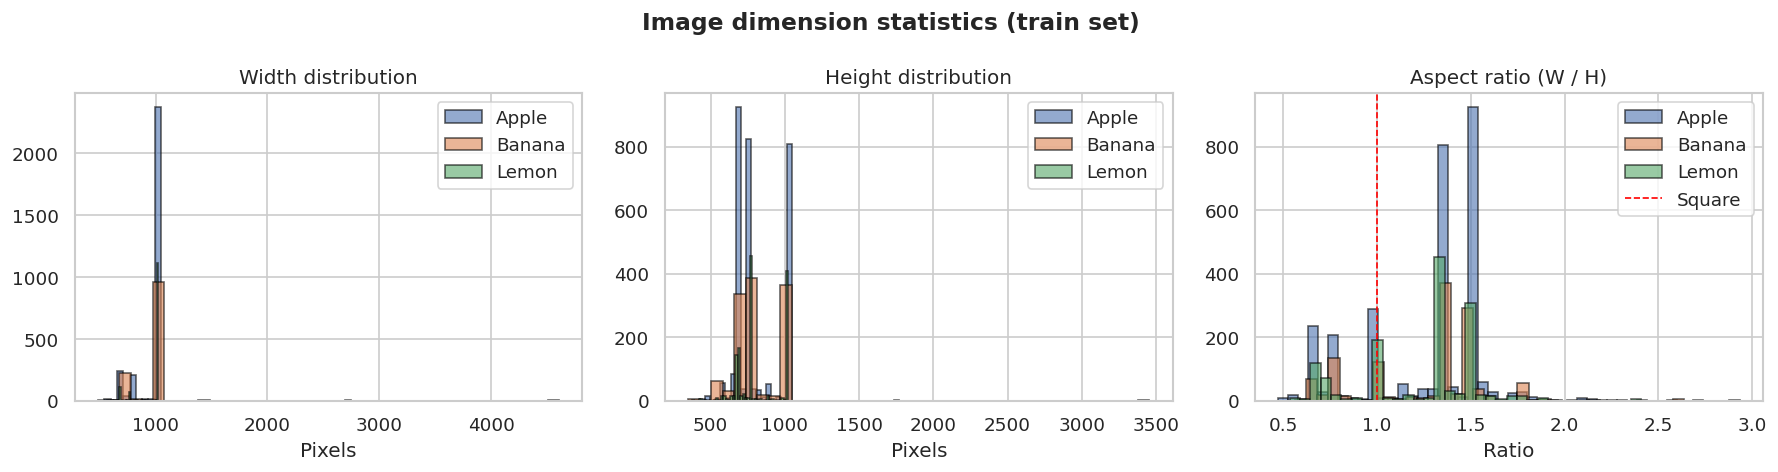

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Width distribution
for cls in CLASSES:
	subset = df_sizes[df_sizes["class"] == cls]
	axes[0].hist(subset["width"], bins=40, alpha=0.6, label=cls, edgecolor="black")
axes[0].set_title("Width distribution")
axes[0].set_xlabel("Pixels")
axes[0].legend()

# Height distribution
for cls in CLASSES:
	subset = df_sizes[df_sizes["class"] == cls]
	axes[1].hist(subset["height"], bins=40, alpha=0.6, label=cls, edgecolor="black")
axes[1].set_title("Height distribution")
axes[1].set_xlabel("Pixels")
axes[1].legend()

# Aspect ratio distribution
for cls in CLASSES:
	subset = df_sizes[df_sizes["class"] == cls]
	axes[2].hist(subset["aspect"], bins=40, alpha=0.6, label=cls, edgecolor="black")
axes[2].set_title("Aspect ratio (W / H)")
axes[2].set_xlabel("Ratio")
axes[2].axvline(1.0, color="red", linestyle="--", linewidth=1, label="Square")
axes[2].legend()

fig.suptitle("Image dimension statistics (train set)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join("..", "reports", "image_dimensions.png"), bbox_inches="tight")
plt.show()

In [10]:
# Per-class size summary
print("Per-class image size summary (train set)")
print("=" * 70)
for cls in CLASSES:
	subset = df_sizes[df_sizes["class"] == cls]
	print(f"\n{cls} ({len(subset)} images):")
	print(f"  Width  — min: {subset['width'].min():>5}, max: {subset['width'].max():>5}, "
		  f"mean: {subset['width'].mean():>6.1f}, median: {subset['width'].median():>6.1f}")
	print(f"  Height — min: {subset['height'].min():>5}, max: {subset['height'].max():>5}, "
		  f"mean: {subset['height'].mean():>6.1f}, median: {subset['height'].median():>6.1f}")
	print(f"  Aspect — min: {subset['aspect'].min():>5.2f}, max: {subset['aspect'].max():>5.2f}, "
		  f"mean: {subset['aspect'].mean():>5.2f}")

Per-class image size summary (train set)

Apple (2913 images):
  Width  — min:   485, max:  2746, mean:  969.4, median: 1024.0
  Height — min:   394, max:  1767, mean:  806.5, median:  768.0
  Aspect — min:  0.47, max:  2.60, mean:  1.26

Banana (1209 images):
  Width  — min:   576, max:  4608, mean:  970.9, median: 1024.0
  Height — min:   349, max:  3456, mean:  812.1, median:  768.0
  Aspect — min:  0.56, max:  2.93, mean:  1.25

Lemon (1352 images):
  Width  — min:   546, max:  1024, mean:  971.3, median: 1024.0
  Height — min:   374, max:  1024, mean:  818.2, median:  768.0
  Aspect — min:  0.53, max:  2.74, mean:  1.24


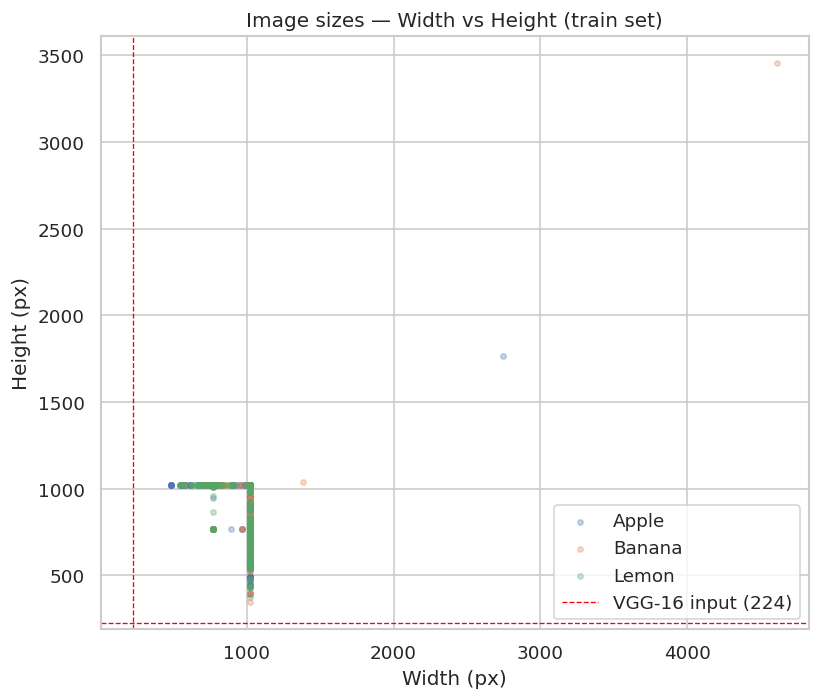

In [11]:
fig, ax = plt.subplots(figsize=(7, 6))
for cls in CLASSES:
	subset = df_sizes[df_sizes["class"] == cls]
	ax.scatter(subset["width"], subset["height"], alpha=0.3, s=10, label=cls)

# Mark the VGG-16 input size
ax.axvline(224, color="red", linestyle="--", linewidth=0.8)
ax.axhline(224, color="red", linestyle="--", linewidth=0.8, label="VGG-16 input (224)")
ax.set_xlabel("Width (px)")
ax.set_ylabel("Height (px)")
ax.set_title("Image sizes — Width vs Height (train set)")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join("..", "reports", "size_scatter.png"), bbox_inches="tight")
plt.show()

## 5. Pixel intensity (colour channel) analysis

A quick check on the mean RGB values to see if colour is a strong discriminator
and whether the images need normalisation beyond simple [0, 1] scaling.

In [12]:
def sample_channel_means(base_dir, cls, n=200, target_size=(224, 224)):
	"""Compute per-channel mean for a random sample of images."""
	ext = ("*.jpg", "*.jpeg", "*.png")
	paths = []
	cls_dir = os.path.join(base_dir, cls)
	for pattern in ext:
		paths.extend(glob.glob(os.path.join(cls_dir, pattern)))
	random.shuffle(paths)
	paths = paths[:n]

	means = []
	for p in paths:
		try:
			img = Image.open(p).convert("RGB").resize(target_size)
			arr = np.array(img, dtype=np.float32) / 255.0
			means.append(arr.mean(axis=(0, 1)))  # shape (3,)
		except Exception:
			continue
	return np.array(means)  # shape (N, 3)


channel_data = {}
for cls in CLASSES:
	channel_data[cls] = sample_channel_means(TRAIN_DIR, cls, n=200)
	mu = channel_data[cls].mean(axis=0)
	print(f"{cls:>8s}  R={mu[0]:.3f}  G={mu[1]:.3f}  B={mu[2]:.3f}")

   Apple  R=0.498  G=0.429  B=0.336
  Banana  R=0.482  G=0.440  B=0.315
   Lemon  R=0.516  G=0.473  B=0.339


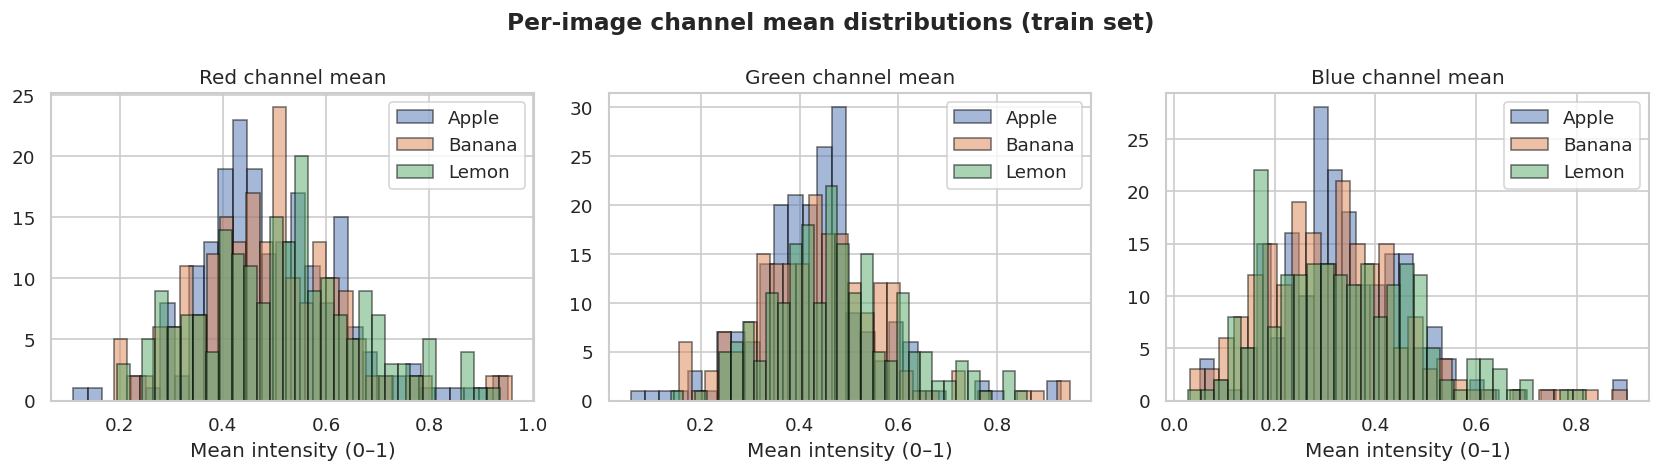

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
channel_names = ["Red", "Green", "Blue"]
channel_colors = ["#e74c3c", "#27ae60", "#2980b9"]

for ch_idx in range(3):
	ax = axes[ch_idx]
	for cls in CLASSES:
		vals = channel_data[cls][:, ch_idx]
		ax.hist(vals, bins=30, alpha=0.5, label=cls, edgecolor="black")
	ax.set_title(f"{channel_names[ch_idx]} channel mean")
	ax.set_xlabel("Mean intensity (0–1)")
	ax.legend()

fig.suptitle("Per-image channel mean distributions (train set)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join("..", "reports", "channel_means.png"), bbox_inches="tight")
plt.show()

## 6. Observations and potential impact on training

### Dataset summary

| Property | Value |
|----------|-------|
| Source | Open Images V7 (detection → crop patches) |
| Classes | Apple, Banana, Lemon |
| Train / Test split | 75% / 25% |
| Random seed | 42 |

### Key observations

1. **Varying image sizes** — Because images are bounding-box crops from detection
   annotations, they come in many different resolutions and aspect ratios.
   All images must be resized to **224 × 224** for VGG input. This resizing
   will distort images with extreme aspect ratios and may affect performance.

2. **Class distribution** — Check the bar chart above.  If one class has
   significantly fewer images, the model may be biased toward the majority class.
   Mitigations: class weights, oversampling, or augmentation focused on the
   minority class.

3. **Visual similarity** — Apples and lemons can look similar in shape
   (round) and sometimes in colour (green apples vs lemons).  This may lead to
   confusion between these two classes.  The confusion matrix (in later
   experiments) will quantify this.

4. **Background and context variation** — Some crops include significant
   background (table, hand, tree).  Others are tightly cropped around the fruit.
   This inconsistency means the model must learn to focus on the fruit itself,
   not the surrounding context.  Data augmentation (random crop, translate) will
   help with this.

5. **Colour as a feature** — The RGB channel analysis shows that colour is
   a strong discriminator: bananas are yellow (high R and G, low B), apples
   are red/green, lemons are yellow-green. However, this also means the model
   may over-rely on colour, making it vulnerable to unusual specimens (green
   bananas, yellow apples).

6. **Image quality** — Some OIV7 crops may be blurry, low-resolution, or
   partially occluded.  These noisy samples can slow convergence and reduce
   final accuracy.  A manual quality check or outlier removal could help
   but is not strictly required.

### Preprocessing plan for training

- Resize all images to **224 × 224** (VGG-16 / VGG-19 input size)
- Normalise pixel values to `[0, 1]` (divide by 255) or use the Keras
  `preprocess_input` function for pretrained models
- Fixed random seed (`42`) for reproducibility
- Apply data augmentation in Experiment 3: random rotation, random translation,
  random crop